# HCC diagnostics: reconstruction, sensitivity, diet adjustment, and cutoff stability

This notebook runs four diagnostic analyses of the HCC worked example and writes the supplementary figures. Every stage reuses the preprocessing and the reference model configuration of `03_hcc.ipynb`.

The stages are:

1. imports, run settings, and output locations,
2. helper functions for data loading, model fitting, edge tables, and network comparison,
3. the input data,
4. the reference model and its correlation estimate,
5. Stage A, reconstruction diagnostics, which supplies `TableS1.csv` and `TableS1.tex`,
6. Stage B, sensitivity to the training seed, latent dimension, and number of epochs, which supplies panels (a) to (c) of `FigureS4.pdf`,
7. Stage C, diet adjustment, which produces `FigureS6.pdf`,
8. Stage D, cutoff choice and subsampling stability, which produces `FigureS5.pdf`,
9. the three supplementary figures and Table S1, and
10. the key numbers reported in the manuscript.

Timing is recorded for the main computational steps and summarized at the end.

## 1. Imports and run settings

`RUN_FITS = True` runs every model fit. Setting it to `False` skips all fitting and rebuilds the figures and the key-numbers table from the CSVs saved by an earlier run. `SMOKE = True` runs a reduced configuration and writes to a separate directory, so the full-scale results are never overwritten.

In [3]:
import gc
import itertools
import os
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from networkx.algorithms.community import louvain_communities
from scipy import stats
from sklearn.metrics import normalized_mutual_info_score

from metvae.compute_corr import _compute_correlation
from metvae.model import MetVAE

%matplotlib inline

sns.set_theme(style="whitegrid")

# Run settings.
RUN_FITS = True
SMOKE = False
WORKERS = -1

# Reference settings of the HCC worked example.
ZERO_PROPORTION_THRESHOLD = 0.30
REFERENCE_SEED = 0
REFERENCE_EPOCHS = 1000
REFERENCE_LEARNING_RATE = 1e-2
REFERENCE_BATCH_SIZE = 100
REFERENCE_NUM_SIM = 100
REFERENCE_FDR_METHOD = 'fdr_bh'
REFERENCE_FDR_CUTOFF = 0.001
REFERENCE_EDGE_CUTOFF = 0.70
REFERENCE_COVARIATES = ('diet',)

# Absolute correlation cutoff passed to get_corr; smaller entries are stored as exact zeros.
CORR_THRESHOLD = 0.2

# Stage-specific constants.
PAIR_SAMPLE_SIZE = 200_000
SWEEP_CUTOFFS = (0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9)
SUBSAMPLE_FRACTION = 0.80
SUBSAMPLE_SEED_BASE = 1000
MIN_COMMUNITY_SIZE_SWEEP = 5
MIN_COMMUNITY_SIZE_STABILITY = 10

# Case-insensitive regular expressions defining the annotation classes. Each class is an
# (inclusion, exclusion) pair; a feature belongs to the class when its Compound_Name matches
# the inclusion pattern and does not match the exclusion pattern.
ANNOTATION_CLASSES = {
    'FAEE': (r'(?<![a-z])ethyl ester|(?<![a-z])ethyl\s|FAEE',
             r'phosph|glycer|tryptophan|amine|amino|methyl ester'),
    'bile_acid': (r'cholic|cholate|bile acid|cholan', None),
    'monoacylglycerol': (r'mono(?:palmit|elaid|ole|linole|linolen|stear|myrist|arachid)|'
                         r'monoacylglycerol|monoglycer|rac-glycerol|mono\w*-sn-glycerol',
                         r'phosph'),
    'fatty_acid': (r'(?:hexadecanoic|octadecanoic|octadecenoic|octadecadienoic|oleic|linoleic|'
                   r'linolenic|palmitic|stearic|arachidonic|docosahexaenoic|eicosapentaenoic|'
                   r'myristic|palmitoleic) acid|fatty acid',
                   r'ester|ethyl|glycer|oyl|amide|carnitine|phosph'),
}

# Reduced settings used when SMOKE is True.
NUM_SIM = 5 if SMOKE else REFERENCE_NUM_SIM
MAX_EPOCHS = 20 if SMOKE else REFERENCE_EPOCHS
N_SUBSAMPLES = 2 if SMOKE else 20
SUBSAMPLE_NUM_SIM = 5 if SMOKE else 50

DATA_DIR = '../data'
CHECKPOINT_PATH = '../results/intermediate_results/hcc_checkpoint.pth'
OUT_DIR = '../results/intermediate_results/smoke' if SMOKE else '../results/intermediate_results'
FIG_DIR = '../results/figures/smoke' if SMOKE else '../results/figures'
USE_CHECKPOINT = (not SMOKE) and os.path.exists(CHECKPOINT_PATH)

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

step_times = {}

def print_step_time(step_name, start_time):
    elapsed = time.perf_counter() - start_time
    step_times[step_name] = elapsed
    print(f"{step_name} finished in {elapsed:.2f} seconds")

print('RUN_FITS:', RUN_FITS)
print('SMOKE:', SMOKE)
print('Reference model from checkpoint:', USE_CHECKPOINT)
print('Intermediate results:', OUT_DIR)
print('Figures:', FIG_DIR)

RUN_FITS: False
SMOKE: False
Reference model from checkpoint: True
Intermediate results: ../results/intermediate_results
Figures: ../results/figures


## 2. Helper functions

The first cell collects data loading and model fitting, the second the conversion of a correlation matrix into an edge table together with the network comparison metrics, and the third the input and output helpers.

In [5]:
def load_hcc_data(data_dir, zero_threshold=ZERO_PROPORTION_THRESHOLD):
    """Load and preprocess the HCC tables.

    The steps reproduce the worked example: drop the first nine MS1 columns, strip the
    suffix from the sample column names, drop duplicated sample columns, restrict the
    metadata to antibiotics == 'No', intersect the sample identifiers, transpose to samples
    by features, and keep features whose proportion of zeros is at most zero_threshold.
    Returns the abundance matrix, the aligned sample metadata, and the MS2 annotation table.
    """
    df_ms1 = pd.read_csv(os.path.join(data_dir, 'hcc_ms1.csv'), index_col=0)
    df_ms1.index = df_ms1.index.astype(str)

    df_ms2 = pd.read_table(os.path.join(data_dir, 'hcc_ms2.tsv'))
    df_ms2 = df_ms2.set_index('#Scan#')
    df_ms2.index = df_ms2.index.astype(str)
    df_ms2 = df_ms2.sort_values(by='Compound_Name')

    smd = pd.read_table(os.path.join(data_dir, 'hcc_sample_metadata.txt'))
    smd = smd.set_index('host_subject_id')
    smd['HCC'] = smd['HCC'].map({True: 'Yes', False: 'No'})
    smd['antibiotics'] = smd['antibiotics'].str.strip().replace(
        {'Yes (Ampicillin, Vancomycin, Neomycin sulfate and Metronidazole )': 'Yes'}
    )

    df_ms1 = df_ms1.iloc[:, 9:]
    df_ms1.columns = [str(c).split('_')[0] for c in df_ms1.columns]
    df_ms1 = df_ms1.loc[:, ~df_ms1.columns.duplicated()]

    smd = smd[smd['antibiotics'].eq('No')].copy()
    samp_ids = smd.index.intersection(df_ms1.columns)
    df_ms1 = df_ms1.loc[:, samp_ids]
    smd = smd.loc[samp_ids].copy()

    df_abundance = df_ms1.T
    proportion_zeros = (df_abundance == 0).mean()
    df_abundance = df_abundance.loc[:, proportion_zeros <= zero_threshold].copy()
    return df_abundance, smd, df_ms2


def smoke_subset(df_abundance, smd, n_features=300, n_samples=120, seed=0):
    """Return a small subset of the data, used when SMOKE is True.

    Samples are drawn separately within each level of diet so that both levels remain
    present. Features are drawn at random among those whose proportion of zeros within the
    retained samples is at most ZERO_PROPORTION_THRESHOLD.
    """
    rng = np.random.default_rng(seed)
    n_samples = min(n_samples, df_abundance.shape[0])

    groups = smd['diet'].astype(str)
    chosen = []
    for level in sorted(groups.unique()):
        ids = groups.index[groups == level].tolist()
        take = max(1, int(round(n_samples * len(ids) / len(groups))))
        take = min(take, len(ids))
        chosen.extend(rng.choice(ids, size=take, replace=False).tolist())
    chosen = [s for s in df_abundance.index if s in set(chosen)][:n_samples]

    sub = df_abundance.loc[chosen]
    zero_prop = (sub == 0).mean()
    eligible = zero_prop.index[zero_prop <= ZERO_PROPORTION_THRESHOLD]
    n_features = min(n_features, len(eligible))
    feats = rng.choice(np.asarray(eligible), size=n_features, replace=False)
    feats = [f for f in df_abundance.columns if f in set(feats)]
    return sub.loc[:, feats].copy(), smd.loc[chosen].copy()


def build_model(df, smd, latent_dim, seed, covariates):
    """Construct a MetVAE object without training it.

    A latent_dim of None selects min(n, d) after the internal zero filtering. The argument
    covariates is a sequence of categorical column names in smd; pass None or an empty
    sequence for an unadjusted model.
    """
    covariate_keys = list(covariates) if covariates else None
    meta = smd if covariate_keys else None
    return MetVAE(
        data=df,
        features_as_rows=False,
        meta=meta,
        categorical_covariate_keys=covariate_keys,
        latent_dim=latent_dim,
        hidden_dims=None,
        use_gpu=False,
        seed=seed,
    )


def fit_model(df, smd, latent_dim, seed, max_epochs, covariates,
              learning_rate=REFERENCE_LEARNING_RATE, batch_size=REFERENCE_BATCH_SIZE):
    """Construct and train a MetVAE model and return it.

    Training uses num_workers = 0 and log_every_n_steps = 1, matching the reference fit.
    """
    model = build_model(df, smd, latent_dim, seed, covariates)
    model.train(
        batch_size=batch_size,
        num_workers=0,
        max_epochs=max_epochs,
        learning_rate=learning_rate,
        log_every_n_steps=1,
    )
    return model


def load_checkpoint_model(df, smd, checkpoint, latent_dim=None, seed=REFERENCE_SEED,
                          covariates=REFERENCE_COVARIATES):
    """Rebuild the reference model and restore the saved checkpoint weights."""
    model = build_model(df, smd, latent_dim, seed, covariates)
    ckpt = torch.load(checkpoint, map_location='cpu', weights_only=False)
    model.model.load_state_dict(ckpt['model_state_dict'])
    model.train_loss = ckpt.get('train_loss', [])
    model.model.eval()
    return model


def sparse_estimate(model, num_sim=REFERENCE_NUM_SIM, workers=-1, seed=REFERENCE_SEED,
                    threshold=CORR_THRESHOLD, p_adj_method=REFERENCE_FDR_METHOD,
                    cutoff=REFERENCE_FDR_CUTOFF):
    """Run get_corr followed by sparse_by_p and return the sparse matrix.

    Only the sparse_estimate entry is retained; the other dense matrices returned by
    sparse_by_p are released immediately to limit peak memory.
    """
    model.get_corr(num_sim=num_sim, workers=workers, threshold=threshold, seed=seed)
    result = model.sparse_by_p(p_adj_method=p_adj_method, cutoff=cutoff)
    out = result['sparse_estimate']
    for key in ('estimate', 'p_value', 'q_value'):
        result.pop(key, None)
    del result
    return out


def dense_estimate(model):
    """Return the cached get_corr estimate as a dense labelled matrix."""
    if model.corr_outputs is None:
        raise ValueError('Call get_corr before dense_estimate.')
    arr = model.corr_outputs['estimate'].to_dense().cpu().numpy()
    return pd.DataFrame(arr, index=model.feature_name, columns=model.feature_name)


def observed_correlation(model, threshold=0.0):
    """Correlation computed from the observed, covariate-adjusted abundances.

    The matrix model.clr_data carries NaN wherever the raw value was zero, so
    exp(clr_data + shift) has NaN in those positions and the correlation excludes them
    pairwise. No entry is imputed.
    """
    obs = torch.exp(model.clr_data + model.shift)
    rho = _compute_correlation(data=obs, threshold=threshold)
    arr = rho.to_dense().cpu().numpy()
    del rho, obs
    return pd.DataFrame(arr, index=model.feature_name, columns=model.feature_name)

In [6]:
def edge_table(sparse_df, cutoff=REFERENCE_EDGE_CUTOFF):
    """Convert a symmetric correlation matrix into a long edge table.

    Returns the strict upper triangle entries with |correlation| >= cutoff, sorted by
    decreasing absolute correlation, with columns source, target, and correlation.
    """
    values = sparse_df.to_numpy()
    names = np.asarray(sparse_df.index, dtype=object)
    d = values.shape[0]
    keep = np.abs(values) >= cutoff
    keep &= np.triu(np.ones((d, d), dtype=bool), k=1)
    rows, cols = np.nonzero(keep)
    out = pd.DataFrame(
        {
            'source': names[rows].astype(str),
            'target': names[cols].astype(str),
            'correlation': values[rows, cols],
        }
    )
    out = out.sort_values('correlation', key=np.abs, ascending=False)
    return out.reset_index(drop=True)


def edge_key_set(edges):
    """Return the undirected edge set as a set of order-normalized pairs."""
    if edges is None or edges.empty:
        return set()
    src = edges['source'].astype(str).to_numpy()
    tgt = edges['target'].astype(str).to_numpy()
    lo = np.where(src <= tgt, src, tgt)
    hi = np.where(src <= tgt, tgt, src)
    return set(zip(lo.tolist(), hi.tolist()))


def jaccard(set_a, set_b):
    """Jaccard index of two sets, returning NaN when both sets are empty."""
    a, b = set(set_a), set(set_b)
    union = len(a | b)
    if union == 0:
        return float('nan')
    return len(a & b) / union


def correlate(x, y, method='pearson'):
    """Pearson or Spearman correlation of two vectors, returning NaN on degeneracy."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x, y = x[finite], y[finite]
    if x.size < 3 or np.std(x) == 0 or np.std(y) == 0:
        return float('nan')
    if method == 'spearman':
        return float(stats.spearmanr(x, y).statistic)
    return float(stats.pearsonr(x, y).statistic)


def corr_over_union(mat_a, mat_b, method='pearson'):
    """Correlation between two correlation estimates over their union support.

    The union support is the set of strict upper triangle positions at which at least one
    of the two matrices is nonzero. Both matrices are first restricted to their shared
    feature names. Returns the correlation coefficient and the number of positions used.
    """
    shared = [f for f in mat_a.index if f in set(mat_b.index)]
    if len(shared) < 3:
        return float('nan'), 0
    a = mat_a.loc[shared, shared].to_numpy()
    b = mat_b.loc[shared, shared].to_numpy()
    mask = np.triu(np.ones(a.shape, dtype=bool), k=1)
    mask &= (a != 0) | (b != 0)
    x, y = a[mask], b[mask]
    n = int(x.size)
    if n < 3:
        return float('nan'), n
    return correlate(x, y, method), n


def build_graph(edges):
    """Build an undirected networkx graph from an edge table."""
    graph = nx.Graph()
    if edges is None or edges.empty:
        return graph
    for row in edges.itertuples(index=False):
        graph.add_edge(str(row.source), str(row.target), weight=float(row.correlation))
    return graph


def communities(graph):
    """Louvain community labels keyed by node name, computed with seed 0."""
    if graph.number_of_nodes() == 0:
        return {}
    parts = louvain_communities(graph, seed=0)
    return {node: idx for idx, part in enumerate(parts) for node in part}


def nmi(labels_a, labels_b):
    """Normalized mutual information of two labelings over their shared nodes.

    Returns the score and the number of shared nodes, and returns NaN when fewer than two
    nodes are shared.
    """
    shared = sorted(set(labels_a) & set(labels_b))
    if len(shared) < 2:
        return float('nan'), len(shared)
    a = [labels_a[node] for node in shared]
    b = [labels_b[node] for node in shared]
    return float(normalized_mutual_info_score(a, b)), len(shared)


def compare_networks(edges_ref, edges_alt, mat_ref=None, mat_alt=None):
    """Summarize the agreement between a reference and an alternative network.

    Reports edge and node counts, the Jaccard index of the edge sets, the fraction of
    reference edges recovered, the normalized mutual information of the Louvain
    communities, and, when both matrices are supplied, the Pearson correlation of the
    estimates over their union support.
    """
    keys_ref = edge_key_set(edges_ref)
    keys_alt = edge_key_set(edges_alt)
    nodes_ref = {node for edge in keys_ref for node in edge}
    nodes_alt = {node for edge in keys_alt for node in edge}
    labels_ref = communities(build_graph(edges_ref))
    labels_alt = communities(build_graph(edges_alt))
    score, shared_nodes = nmi(labels_ref, labels_alt)
    out = {
        'n_edges_ref': len(keys_ref),
        'n_edges_alt': len(keys_alt),
        'n_nodes_ref': len(nodes_ref),
        'n_nodes_alt': len(nodes_alt),
        'edge_jaccard': jaccard(keys_ref, keys_alt),
        'frac_ref_edges_recovered': (
            len(keys_ref & keys_alt) / len(keys_ref) if keys_ref else float('nan')
        ),
        'node_jaccard': jaccard(nodes_ref, nodes_alt),
        'community_nmi': score,
        'n_shared_nodes': shared_nodes,
    }
    if mat_ref is not None and mat_alt is not None:
        value, n_used = corr_over_union(mat_ref, mat_alt, method='pearson')
        out['estimate_pearson_union'] = value
        out['n_union_entries'] = n_used
    return out


def annotation_classes(df_ms2, feature_names, classes=None):
    """Assign features to annotation classes by case-insensitive regular expression.

    The table df_ms2 is indexed by #Scan# and carries the annotation in Compound_Name. A
    feature may belong to more than one class. Each class is given as an inclusion pattern
    or as an (inclusion, exclusion) pair.
    """
    classes = ANNOTATION_CLASSES if classes is None else classes
    present = set(str(f) for f in feature_names)
    names = df_ms2['Compound_Name'].astype(str)
    out = {}
    for label, patterns in classes.items():
        inclusion, exclusion = patterns if isinstance(patterns, tuple) else (patterns, None)
        hit = names.str.contains(inclusion, case=False, regex=True, na=False)
        if exclusion:
            hit &= ~names.str.contains(exclusion, case=False, regex=True, na=False)
        ids = {str(i) for i in names.index[hit]}
        out[label] = ids & present
    return out

In [7]:
def write_result(frame, name):
    """Write a tidy CSV into the intermediate-results directory and return its path."""
    path = os.path.join(OUT_DIR, name)
    frame.to_csv(path, index=False)
    return path


def read_result(name, **kwargs):
    """Read a CSV written by an earlier run.

    Returns None when the file is absent and an empty frame when it holds no rows.
    """
    path = os.path.join(OUT_DIR, name)
    if not os.path.exists(path):
        print(f'Missing {name}; the dependent output is left empty.')
        return None
    try:
        return pd.read_csv(path, **kwargs)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def save_sparse_matrix(path, matrix):
    """Store a labelled symmetric matrix as its nonzero strict upper triangle.

    The diagonal is stored separately. Only the upper triangle is written, which halves the
    file size relative to storing both triangles.
    """
    values = matrix.to_numpy()
    d = values.shape[0]
    upper = np.triu(np.ones((d, d), dtype=bool), k=1)
    upper &= values != 0
    rows, cols = np.nonzero(upper)
    np.savez_compressed(
        path,
        rows=rows.astype(np.int32),
        cols=cols.astype(np.int32),
        vals=values[rows, cols].astype(np.float64),
        diag=np.diag(values).astype(np.float64),
        names=np.asarray([str(f) for f in matrix.index], dtype=object),
    )
    return path


def load_sparse_matrix(path):
    """Read a labelled symmetric matrix stored by save_sparse_matrix."""
    with np.load(path, allow_pickle=True) as handle:
        names = [str(f) for f in handle['names']]
        d = len(names)
        out = np.zeros((d, d), dtype=np.float64)
        rows, cols = handle['rows'], handle['cols']
        vals = handle['vals']
        out[rows, cols] = vals
        out[cols, rows] = vals
        np.fill_diagonal(out, handle['diag'])
    return pd.DataFrame(out, index=names, columns=names)


def safe_mean(values):
    """Mean of a sequence of numbers, returning NaN for an empty sequence."""
    values = np.asarray(values, dtype=float)
    return float(values.mean()) if values.size else float('nan')

## 3. Load the input data

The abundance matrix, the sample metadata, and the MS2 annotation table are loaded and preprocessed as in `03_hcc.ipynb`. When `SMOKE` is `True` the data are subset to about 300 features and 120 samples.

In [9]:
step_start = time.perf_counter()

df_abundance, smd, df_ms2 = load_hcc_data(DATA_DIR)
if SMOKE:
    df_abundance, smd = smoke_subset(df_abundance, smd)

n_samples, n_features = df_abundance.shape
print_step_time('Load and preprocess data', step_start)

print('# samples:', n_samples)
print('# features:', n_features)
print('Proportion of zeros: %.2f %%' % (100 * (df_abundance == 0).to_numpy().mean()))
display(smd['diet'].value_counts())

Load and preprocess data finished in 0.91 seconds
# samples: 411
# features: 7217
Proportion of zeros: 4.63 %


diet
HFD    302
NC     109
Name: count, dtype: int64

## 4. Reference model and reference estimate

The reference model is the diet-adjusted fit of `03_hcc.ipynb`. Its correlation estimate is computed once here, with 100 imputations and seed 0, and is reused by every later stage. The dense estimate is the comparison target of Stage A, and the sparse estimate obtained by Benjamini-Hochberg filtering at 0.001 is the reference network of Stages B, C, and D.

In [11]:
reference_model = None
reference_dense = None
reference_sparse = None

if RUN_FITS:
    step_start = time.perf_counter()
    if USE_CHECKPOINT:
        reference_model = load_checkpoint_model(
            df_abundance, smd, CHECKPOINT_PATH, latent_dim=min(df_abundance.shape)
        )
    else:
        reference_model = fit_model(
            df_abundance, smd, latent_dim=min(df_abundance.shape), seed=REFERENCE_SEED,
            max_epochs=MAX_EPOCHS, covariates=REFERENCE_COVARIATES,
        )
    print_step_time('Build the reference model', step_start)

    step_start = time.perf_counter()
    reference_model.get_corr(
        num_sim=NUM_SIM, workers=WORKERS, threshold=CORR_THRESHOLD, seed=REFERENCE_SEED
    )
    reference_dense = dense_estimate(reference_model)
    print_step_time('Reference get_corr', step_start)

    step_start = time.perf_counter()
    result = reference_model.sparse_by_p(
        p_adj_method=REFERENCE_FDR_METHOD, cutoff=REFERENCE_FDR_CUTOFF
    )
    reference_sparse = result['sparse_estimate']
    for key in ('estimate', 'p_value', 'q_value'):
        result.pop(key, None)
    del result
    save_sparse_matrix(os.path.join(OUT_DIR, 'reference_estimate.npz'), reference_sparse)
    print_step_time('Reference sparsification', step_start)

    print('Reference sparse estimate shape:', reference_sparse.shape)
    print('Edges at |r| >= 0.7:', len(edge_table(reference_sparse, REFERENCE_EDGE_CUTOFF)))
else:
    print('RUN_FITS is False; the reference estimate is not computed.')

RUN_FITS is False; the reference estimate is not computed.


## 5. Stage A: reconstruction diagnostics

The correlation matrix computed from the observed abundances alone, with zeros excluded pairwise, is compared against the MetVAE multiple-imputation estimate. Agreement is reported over pairs for which at least one estimate has absolute correlation >= 0.2 (Table S1), pooled and separately for pairs in which both features are fully observed and pairs in which at least one feature contains a zero.

In [13]:
def observed_vs_metvae(model, metvae, edge_cutoff):
    """Compare the observed-only and MetVAE correlation matrices.

    Agreement is summarized over the union support, defined as the pairs at which at least
    one of the two matrices has |r| >= CORR_THRESHOLD, for all pairs and separately for
    pairs in which both features are fully observed and pairs in which at least one feature
    contains a zero. Returns the per-stratum summary table for Table S1.
    """
    observed = observed_correlation(model, threshold=0.0)

    obs_values = observed.to_numpy()
    met_values = metvae.to_numpy()
    d = obs_values.shape[0]

    support = np.triu(np.ones((d, d), dtype=bool), k=1)
    support &= (np.abs(obs_values) >= CORR_THRESHOLD) | (np.abs(met_values) >= CORR_THRESHOLD)
    has_zero = model.num_zero.cpu().numpy() > 0
    any_zero = has_zero[:, None] | has_zero[None, :]

    rows, cols = np.nonzero(support)
    x_obs = obs_values[rows, cols]
    x_met = met_values[rows, cols]
    stratum = np.where(any_zero[rows, cols], 'any_zero', 'both_observed')
    del support, any_zero, rows, cols

    edges_obs = edge_key_set(edge_table(observed, edge_cutoff))
    edges_met = edge_key_set(edge_table(metvae, edge_cutoff))
    del obs_values, met_values, observed

    records = []
    for label in ('all', 'both_observed', 'any_zero'):
        keep = slice(None) if label == 'all' else (stratum == label)
        xs, ys = x_obs[keep], x_met[keep]
        records.append(
            {
                'stratum': label,
                'n_pairs': int(xs.size),
                'pearson': correlate(xs, ys, 'pearson'),
                'n_edges_observed': int(np.sum(np.abs(xs) >= edge_cutoff)),
                'n_edges_metvae': int(np.sum(np.abs(ys) >= edge_cutoff)),
                'edge_jaccard': jaccard(
                    set(np.flatnonzero(np.abs(xs) >= edge_cutoff).tolist()),
                    set(np.flatnonzero(np.abs(ys) >= edge_cutoff).tolist()),
                ),
            }
        )
    strata = pd.DataFrame.from_records(records)
    strata.loc[strata['stratum'] == 'all', 'edge_jaccard'] = jaccard(edges_obs, edges_met)

    return strata


In [14]:
if RUN_FITS:
    step_start = time.perf_counter()
    recon_strata = observed_vs_metvae(
        reference_model, reference_dense, REFERENCE_EDGE_CUTOFF
    )
    write_result(recon_strata, 'recon_observed_vs_metvae.csv')
    print_step_time('Stage A: observed against MetVAE correlations', step_start)

    # The dense reference estimate is no longer needed.
    del reference_dense
    reference_dense = None
    gc.collect()
else:
    recon_strata = read_result('recon_observed_vs_metvae.csv')

display(recon_strata)


,stratum,n_pairs,pearson,spearman,mean_abs_difference,n_edges_observed,n_edges_metvae,edge_jaccard
0,all,8335689,0.899123,0.889201,0.094218,43317,22470,0.490214
1,both_observed,67974,0.983425,0.980755,0.038755,1509,1649,0.860931
2,any_zero,8267715,0.898234,0.888275,0.094674,41808,20821,0.475394


## 6. Stage B: sensitivity to the training settings

Nine configurations vary one setting at a time around the reference: the retrained reference, training seeds 1 and 2, latent dimensions 16, 64, and 128, and 250, 500, and 2000 epochs. The imputation seed is fixed at 0 for every configuration, so differences reflect the training settings and not the imputation draws. Each configuration is compared with the retrained reference and with the reference estimate of Section 4.

In [16]:
CONFIGURATIONS = [
    {'config': 'reference', 'latent_dim': None, 'seed': 0, 'max_epochs': 1000},
    {'config': 'seed_1', 'latent_dim': None, 'seed': 1, 'max_epochs': 1000},
    {'config': 'seed_2', 'latent_dim': None, 'seed': 2, 'max_epochs': 1000},
    {'config': 'latent_16', 'latent_dim': 16, 'seed': 0, 'max_epochs': 1000},
    {'config': 'latent_64', 'latent_dim': 64, 'seed': 0, 'max_epochs': 1000},
    {'config': 'latent_128', 'latent_dim': 128, 'seed': 0, 'max_epochs': 1000},
    {'config': 'epochs_250', 'latent_dim': None, 'seed': 0, 'max_epochs': 250},
    {'config': 'epochs_500', 'latent_dim': None, 'seed': 0, 'max_epochs': 500},
    {'config': 'epochs_2000', 'latent_dim': None, 'seed': 0, 'max_epochs': 2000},
]


def smoke_configuration(config):
    """Shrink a configuration so that it runs in seconds."""
    out = dict(config)
    scale = 20 / REFERENCE_EPOCHS
    out['max_epochs'] = max(5, int(round(config['max_epochs'] * scale)))
    if out['latent_dim'] is not None:
        out['latent_dim'] = min(out['latent_dim'], 64)
    return out


def sensitivity_estimate_path(name):
    """Path of the saved sparse estimate of one configuration."""
    return os.path.join(OUT_DIR, f'sensitivity_estimate_{name}.npz')

In [17]:
if RUN_FITS:
    records = []
    for order, base_config in enumerate(CONFIGURATIONS):
        config = smoke_configuration(base_config) if SMOKE else base_config
        name = config['config']
        step_start = time.perf_counter()

        latent_dim = config['latent_dim'] or min(df_abundance.shape)
        model = fit_model(
            df_abundance, smd, latent_dim=latent_dim, seed=config['seed'],
            max_epochs=config['max_epochs'], covariates=REFERENCE_COVARIATES,
        )
        sparse = sparse_estimate(model, num_sim=NUM_SIM, workers=WORKERS, seed=REFERENCE_SEED)
        edges = edge_table(sparse, REFERENCE_EDGE_CUTOFF)

        write_result(edges, f'sensitivity_edges_{name}.csv')
        save_sparse_matrix(sensitivity_estimate_path(name), sparse)
        records.append(
            {
                'config_order': order,
                'config': name,
                'latent_dim': latent_dim,
                'seed': config['seed'],
                'max_epochs': config['max_epochs'],
                'num_sim': NUM_SIM,
                'n_features': int(model.feature_dim),
                'n_samples': int(model.sample_dim),
                'final_train_loss': float(model.train_loss[-1]) if model.train_loss else np.nan,
                'n_edges': int(len(edges)),
                'n_nodes': int(len(set(edges['source']) | set(edges['target']))),
            }
        )
        del model, sparse, edges
        gc.collect()
        print_step_time(f'Stage B: fit {name}', step_start)

    sensitivity_runs = pd.DataFrame.from_records(records)
    write_result(sensitivity_runs, 'sensitivity_runs.csv')
else:
    sensitivity_runs = read_result('sensitivity_runs.csv')

display(sensitivity_runs)

,config_order,config,latent_dim,seed,max_epochs,num_sim,n_features,n_samples,final_train_loss,n_edges,n_nodes
0,0,reference,411,0,1000,100,7217,411,1173.403798,22470,3973
1,1,seed_1,411,1,1000,100,7217,411,1519.568843,22532,3968
2,2,seed_2,411,2,1000,100,7217,411,1174.115678,22092,3971
3,3,latent_16,16,0,1000,100,7217,411,10473.571166,41381,4596
4,4,latent_64,64,0,1000,100,7217,411,8939.851862,36679,4487
5,5,latent_128,128,0,1000,100,7217,411,7801.353555,32355,4357
6,6,epochs_250,411,0,250,100,7217,411,1503.622464,22423,3974
7,7,epochs_500,411,0,500,100,7217,411,1929.388092,22467,3973
8,8,epochs_2000,411,0,2000,100,7217,411,1721.346213,22859,3980


Each configuration is now compared with the retrained reference and with the reference estimate of Section 4. The saved estimates are loaded one at a time so that at most three dense matrices are held in memory.

In [19]:
if RUN_FITS:
    step_start = time.perf_counter()
    ref_edges = read_result('sensitivity_edges_reference.csv', dtype={'source': str, 'target': str})
    ref_estimate = load_sparse_matrix(sensitivity_estimate_path('reference'))
    checkpoint_edges = edge_table(reference_sparse, REFERENCE_EDGE_CUTOFF)

    records = []
    for row in sensitivity_runs.to_dict(orient='records'):
        name = row['config']
        edges = read_result(f'sensitivity_edges_{name}.csv', dtype={'source': str, 'target': str})
        estimate = load_sparse_matrix(sensitivity_estimate_path(name))

        entry = dict(row)
        entry['comparison'] = 'retrained_reference'
        entry.update(compare_networks(ref_edges, edges, ref_estimate, estimate))
        records.append(entry)

        entry = dict(row)
        entry['comparison'] = 'reference_estimate'
        entry.update(compare_networks(checkpoint_edges, edges, reference_sparse, estimate))
        records.append(entry)

        del edges, estimate
        gc.collect()

    sensitivity_summary = pd.DataFrame.from_records(records)
    write_result(sensitivity_summary, 'sensitivity_summary.csv')
    del ref_edges, ref_estimate, checkpoint_edges
    gc.collect()
    print_step_time('Stage B: compare configurations', step_start)
else:
    sensitivity_summary = read_result('sensitivity_summary.csv')

display(
    sensitivity_summary.loc[
        sensitivity_summary['comparison'] == 'retrained_reference',
        ['config', 'n_edges_alt', 'n_nodes_alt', 'edge_jaccard', 'community_nmi',
         'estimate_pearson_union'],
    ]
)

,config,n_edges_alt,n_nodes_alt,edge_jaccard,community_nmi,estimate_pearson_union
0,reference,22470,3973,1.000000,1.000000,1.000000
2,seed_1,22532,3968,0.950756,0.993596,0.991717
4,seed_2,22092,3971,0.947470,0.992275,0.991834
6,latent_16,41381,4596,0.533369,0.937597,0.926868
8,latent_64,36679,4487,0.605477,0.949252,0.949229
10,latent_128,32355,4357,0.688846,0.965555,0.965277
12,epochs_250,22423,3974,0.956463,0.994021,0.992392
14,epochs_500,22467,3973,0.952424,0.986661,0.991950
16,epochs_2000,22859,3980,0.949467,0.990913,0.991505


## 7. Stage C: diet adjustment

Diet is both the adjustment covariate of the reference analysis and the grouping variable of the study design. Three fits are compared: the diet-adjusted fit on all samples, which is the reference model of Section 4; an unadjusted fit on all samples; and an unadjusted fit on the high-fat-diet samples only. With `categorical_covariate_keys = ['diet']` and `drop_first = True` the single dummy is `diet_NC`, so the adjustment removes the normal-chow effect and centers every sample at the high-fat-diet mean.
Figure S6 reports agreement between adjusted and unadjusted estimates over their full union support (panel a), and edge counts for the three networks (panel b).


In [21]:
DIET_MODEL_LABELS = ('adjusted', 'unadjusted', 'hfd_only')


def annotation_edge_counts(edges_by_model, classes):
    """Count strong edges between annotated classes under each fit."""
    records = []
    labels = sorted(classes)
    for model_label, edges in edges_by_model.items():
        keys = edge_key_set(edges)
        for label_a, label_b in itertools.combinations_with_replacement(labels, 2):
            set_a, set_b = classes[label_a], classes[label_b]
            count = sum(
                1
                for source, target in keys
                if (source in set_a and target in set_b)
                or (source in set_b and target in set_a)
            )
            if label_a == label_b:
                possible = len(set_a) * (len(set_a) - 1) // 2
            else:
                possible = len(set_a) * len(set_b)
            records.append(
                {
                    'model': model_label,
                    'class_a': label_a,
                    'class_b': label_b,
                    'n_features_a': len(set_a),
                    'n_features_b': len(set_b),
                    'n_possible_pairs': possible,
                    'n_edges': count,
                    'edge_density': count / possible if possible else np.nan,
                }
            )
    return pd.DataFrame.from_records(records)


def edge_coefficient_contrast(edges_adjusted, edges_unadjusted, coefficients):
    """Compare diet coefficients across edge categories.

    Each edge is placed in one of three categories: present only without adjustment, present
    under both fits, or present only after adjustment. For each category the distribution of
    the two endpoint values of the absolute diet coefficient is summarized.
    """
    keys_adjusted = edge_key_set(edges_adjusted)
    keys_unadjusted = edge_key_set(edges_unadjusted)
    categories = {
        'unadjusted_only': keys_unadjusted - keys_adjusted,
        'both': keys_unadjusted & keys_adjusted,
        'adjusted_only': keys_adjusted - keys_unadjusted,
    }
    absolute = coefficients.abs()
    records = []
    for label, keys in categories.items():
        if not keys:
            records.append(
                {'edge_category': label, 'n_edges': 0,
                 'median_endpoint_abs_coefficient': np.nan,
                 'q25_endpoint_abs_coefficient': np.nan,
                 'q75_endpoint_abs_coefficient': np.nan,
                 'median_max_endpoint_abs_coefficient': np.nan}
            )
            continue
        pairs = np.array(list(keys))
        left = absolute.reindex(pairs[:, 0]).to_numpy(dtype=float)
        right = absolute.reindex(pairs[:, 1]).to_numpy(dtype=float)
        stacked = np.concatenate([left, right])
        records.append(
            {
                'edge_category': label,
                'n_edges': len(keys),
                'median_endpoint_abs_coefficient': float(np.nanmedian(stacked)),
                'q25_endpoint_abs_coefficient': float(np.nanquantile(stacked, 0.25)),
                'q75_endpoint_abs_coefficient': float(np.nanquantile(stacked, 0.75)),
                'median_max_endpoint_abs_coefficient': float(np.nanmedian(np.fmax(left, right))),
            }
        )
    return pd.DataFrame.from_records(records)


def hexbin_sample(mat_a, mat_b, seed=0, size=PAIR_SAMPLE_SIZE):
    """Subsample the union support of two estimates for the hexbin panel."""
    shared = [f for f in mat_a.index if f in set(mat_b.index)]
    a = mat_a.loc[shared, shared].to_numpy()
    b = mat_b.loc[shared, shared].to_numpy()
    mask = np.triu(np.ones(a.shape, dtype=bool), k=1)
    mask &= (a != 0) | (b != 0)
    rows, cols = np.nonzero(mask)
    rng = np.random.default_rng(seed)
    take = min(size, rows.size)
    idx = rng.choice(rows.size, size=take, replace=False) if take else np.array([], int)
    return pd.DataFrame(
        {'adjusted': a[rows[idx], cols[idx]], 'unadjusted': b[rows[idx], cols[idx]]}
    )

In [22]:
if RUN_FITS:
    step_start = time.perf_counter()

    # (i) diet-adjusted: the reference model and estimate of Section 4.
    diet_estimates = {'adjusted': reference_sparse}
    diet_edges = {'adjusted': edge_table(reference_sparse, REFERENCE_EDGE_CUTOFF)}
    # Retain coefficients for the edge-category comparison; no variance-ratio analysis.
    diet_coefficients = reference_model.confound_coef().iloc[:, 0].copy()
    diet_coefficients.index = diet_coefficients.index.astype(str)

    # The reference model is no longer needed.
    del reference_model
    reference_model = None
    gc.collect()
    print_step_time('Stage C: reference diet coefficients', step_start)

    # (ii) unadjusted, on all samples.
    step_start = time.perf_counter()
    model = fit_model(
        df_abundance, None, latent_dim=min(df_abundance.shape), seed=REFERENCE_SEED,
        max_epochs=MAX_EPOCHS, covariates=None,
    )
    diet_estimates['unadjusted'] = sparse_estimate(
        model, num_sim=NUM_SIM, workers=WORKERS, seed=REFERENCE_SEED
    )
    diet_edges['unadjusted'] = edge_table(diet_estimates['unadjusted'], REFERENCE_EDGE_CUTOFF)
    del model
    gc.collect()
    print_step_time('Stage C: unadjusted fit', step_start)

    # (iii) unadjusted, on the high-fat-diet samples only.
    step_start = time.perf_counter()
    hfd_samples = smd.index[smd['diet'].astype(str) == 'HFD']
    df_hfd = df_abundance.loc[df_abundance.index.intersection(hfd_samples)]
    model = fit_model(
        df_hfd, None, latent_dim=min(df_hfd.shape), seed=REFERENCE_SEED,
        max_epochs=MAX_EPOCHS, covariates=None,
    )
    diet_estimates['hfd_only'] = sparse_estimate(
        model, num_sim=NUM_SIM, workers=WORKERS, seed=REFERENCE_SEED
    )
    diet_edges['hfd_only'] = edge_table(diet_estimates['hfd_only'], REFERENCE_EDGE_CUTOFF)
    del model
    gc.collect()
    print_step_time('Stage C: high-fat-diet fit', step_start)

    for label, table in diet_edges.items():
        write_result(table, f'diet_edges_{label}.csv')
    print('High-fat-diet samples:', df_hfd.shape[0])
else:
    diet_edges = {
        label: read_result(f'diet_edges_{label}.csv', dtype={'source': str, 'target': str})
        for label in DIET_MODEL_LABELS
    }
    diet_estimates = {}

In [23]:
if RUN_FITS:
    step_start = time.perf_counter()
    records = []
    for reference, alternative in itertools.combinations(DIET_MODEL_LABELS, 2):
        row = {
            'comparison': f'{reference}_vs_{alternative}',
            'reference_model': reference,
            'alternative_model': alternative,
        }
        row.update(
            compare_networks(
                diet_edges[reference], diet_edges[alternative],
                diet_estimates[reference], diet_estimates[alternative],
            )
        )
        records.append(row)
    diet_comparison = pd.DataFrame.from_records(records)
    write_result(diet_comparison, 'diet_network_comparison.csv')

    diet_contrast = edge_coefficient_contrast(
        diet_edges['adjusted'], diet_edges['unadjusted'], diet_coefficients
    )
    write_result(diet_contrast, 'diet_edge_coefficients.csv')

    diet_hexbin = hexbin_sample(diet_estimates['adjusted'], diet_estimates['unadjusted'])
    write_result(diet_hexbin, 'diet_hexbin_sample.csv')

    # Only the reference estimate is needed by Stage D.
    del diet_estimates['unadjusted'], diet_estimates['hfd_only']
    gc.collect()
    print_step_time('Stage C: network comparisons', step_start)
else:
    diet_comparison = read_result('diet_network_comparison.csv')
    diet_contrast = read_result('diet_edge_coefficients.csv')

# The class-level edge counts are recomputed from the edge tables on every run.
diet_classes = annotation_classes(df_ms2, df_abundance.columns)
diet_annotation = annotation_edge_counts(diet_edges, diet_classes)
write_result(diet_annotation, 'diet_annotation_edges.csv')
print('Annotated features per class:', {k: len(v) for k, v in diet_classes.items()})

display(diet_comparison[['comparison', 'n_edges_ref', 'n_edges_alt', 'edge_jaccard',
                         'community_nmi', 'estimate_pearson_union']])
display(diet_contrast)

Annotated features per class: {'FAEE': 34, 'bile_acid': 263, 'monoacylglycerol': 40, 'fatty_acid': 29}


,comparison,n_edges_ref,n_edges_alt,edge_jaccard,community_nmi,estimate_pearson_union
0,adjusted_vs_unadjusted,22470,57869,0.342182,0.916204,0.777340
1,adjusted_vs_hfd_only,22470,31202,0.643255,0.941179,0.876758
2,unadjusted_vs_hfd_only,57869,31202,0.316003,0.891415,0.735380


,edge_category,n_edges,median_endpoint_abs_coefficient,q25_endpoint_abs_coefficient,q75_endpoint_abs_coefficient,median_max_endpoint_abs_coefficient
0,unadjusted_only,37387,3.769257,2.952847,4.686235,4.543851
1,both,20482,0.731770,0.441724,1.087598,0.894173
2,adjusted_only,1988,0.723780,0.318479,1.213310,1.213310


## 8. Stage D: cutoff choice and subsampling stability

The cutoff sweep evaluates the reference estimate at absolute correlation cutoffs from 0.5 to 0.9 and reports the agreement of each cutoff with 0.7. The subsampling analysis draws 80 percent of the samples without replacement, stratified by diet, refits the model with the reference settings, and records how often each reference edge is recovered.

In [25]:
def community_sizes(labels):
    """Group nodes by community label."""
    groups = {}
    for node, label in labels.items():
        groups.setdefault(label, set()).add(node)
    return list(groups.values())


def sweep_cutoffs(sparse, cutoffs, reference_cutoff):
    """Summarize the network obtained at each absolute correlation cutoff.

    Reports the number of edges and nodes, the number of connected components, the size of
    the largest component, the number of Louvain communities, the agreement with the
    adjacent cutoff, and the agreement with the reference cutoff.
    """
    tables = {cutoff: edge_table(sparse, cutoff) for cutoff in cutoffs}
    keys = {cutoff: edge_key_set(table) for cutoff, table in tables.items()}
    labels = {cutoff: communities(build_graph(table)) for cutoff, table in tables.items()}

    records = []
    for index, cutoff in enumerate(cutoffs):
        graph = build_graph(tables[cutoff])
        sizes = [len(part) for part in community_sizes(labels[cutoff])]
        components = list(nx.connected_components(graph)) if graph.number_of_nodes() else []
        nmi_reference, shared_reference = nmi(labels[reference_cutoff], labels[cutoff])
        if index == 0:
            nmi_previous, shared_previous = np.nan, 0
        else:
            nmi_previous, shared_previous = nmi(labels[cutoffs[index - 1]], labels[cutoff])
        records.append(
            {
                'cutoff': cutoff,
                'n_edges': len(keys[cutoff]),
                'n_nodes': graph.number_of_nodes(),
                'n_components': len(components),
                'largest_component_size': max((len(c) for c in components), default=0),
                'n_communities': len(sizes),
                'n_communities_min5': int(sum(1 for s in sizes if s >= MIN_COMMUNITY_SIZE_SWEEP)),
                'nmi_vs_reference_cutoff': nmi_reference,
                'n_shared_nodes_vs_reference': shared_reference,
                'nmi_vs_previous_cutoff': nmi_previous,
                'n_shared_nodes_vs_previous': shared_previous,
                'edge_jaccard_vs_reference_cutoff': jaccard(keys[reference_cutoff], keys[cutoff]),
            }
        )
    return pd.DataFrame.from_records(records)


def retained_correlation_quantiles(sparse):
    """Quantiles of |r| among the off-diagonal entries retained by the p-value filter."""
    columns = ['quantile', 'abs_correlation', 'n_retained_pairs', 'frac_at_or_above_0.7']
    values = sparse.to_numpy()
    d = values.shape[0]
    mask = np.triu(np.ones((d, d), dtype=bool), k=1)
    mask &= values != 0
    magnitudes = np.abs(values[mask])
    if magnitudes.size == 0:
        return pd.DataFrame(columns=columns)
    records = [
        {
            'quantile': q,
            'abs_correlation': float(np.quantile(magnitudes, q)),
            'n_retained_pairs': int(magnitudes.size),
            'frac_at_or_above_0.7': float(np.mean(magnitudes >= 0.7)),
        }
        for q in (0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999, 0.9999)
    ]
    return pd.DataFrame.from_records(records, columns=columns)


def stratified_subsample(smd, fraction, seed):
    """Draw a fraction of the samples without replacement within each diet level."""
    rng = np.random.default_rng(seed)
    groups = smd['diet'].astype(str)
    chosen = []
    for level in sorted(groups.unique()):
        ids = np.asarray(groups.index[groups == level])
        take = max(1, int(round(fraction * ids.size)))
        chosen.extend(rng.choice(ids, size=take, replace=False).tolist())
    keep = set(chosen)
    return [s for s in smd.index if s in keep]

In [26]:
if RUN_FITS:
    step_start = time.perf_counter()
    cutoffs = tuple(sorted(set(SWEEP_CUTOFFS) | {REFERENCE_EDGE_CUTOFF}))
    threshold_sweep = sweep_cutoffs(reference_sparse, cutoffs, REFERENCE_EDGE_CUTOFF)
    threshold_quantiles = retained_correlation_quantiles(reference_sparse)
    threshold_reference_edges = edge_table(reference_sparse, REFERENCE_EDGE_CUTOFF)

    write_result(threshold_sweep, 'threshold_sweep.csv')
    write_result(threshold_quantiles, 'threshold_r_quantiles.csv')
    write_result(threshold_reference_edges, 'threshold_reference_edges.csv')
    print_step_time('Stage D: cutoff sweep', step_start)
else:
    threshold_sweep = read_result('threshold_sweep.csv')
    threshold_quantiles = read_result('threshold_r_quantiles.csv')
    threshold_reference_edges = read_result(
        'threshold_reference_edges.csv', dtype={'source': str, 'target': str}
    )

display(threshold_sweep)
display(threshold_quantiles)

,cutoff,n_edges,n_nodes,n_components,largest_component_size,n_communities,n_communities_min5,nmi_vs_reference_cutoff,n_shared_nodes_vs_reference,nmi_vs_previous_cutoff,n_shared_nodes_vs_previous,edge_jaccard_vs_reference_cutoff
0,0.50,255500,6346,117,6053,150,27,0.636263,3973,NaN,0,0.087945
1,0.55,145782,5814,208,5289,244,38,0.739866,3973,0.799165,5814,0.154134
2,0.60,81119,5185,351,4266,383,46,0.821548,3973,0.859540,5185,0.277000
3,0.65,43715,4570,540,3007,573,75,0.908941,3973,0.884391,4570,0.514011
4,0.70,22470,3973,723,1013,742,79,1.000000,3973,0.908941,3973,1.000000
5,0.75,10840,3368,837,230,846,67,0.942499,3368,0.942499,3368,0.482421
6,0.80,5049,2743,864,163,869,52,0.900352,2743,0.952808,2743,0.224700
7,0.85,2388,2135,808,46,808,32,0.882284,2135,0.967657,2135,0.106275
8,0.90,1074,1509,649,20,649,16,0.870728,1509,0.980165,1509,0.047797


,quantile,abs_correlation,n_retained_pairs,frac_at_or_above_0.7
0,0.5000,0.273396,6339279,0.003545
1,0.7500,0.338400,6339279,0.003545
2,0.9000,0.419336,6339279,0.003545
3,0.9500,0.480595,6339279,0.003545
4,0.9900,0.620266,6339279,0.003545
5,0.9950,0.674729,6339279,0.003545
6,0.9990,0.784887,6339279,0.003545
7,0.9999,0.929877,6339279,0.003545


In [27]:
if RUN_FITS:
    records = []
    for replicate in range(N_SUBSAMPLES):
        step_start = time.perf_counter()
        seed = SUBSAMPLE_SEED_BASE + replicate
        samples = stratified_subsample(smd, SUBSAMPLE_FRACTION, seed)
        df_sub = df_abundance.loc[samples]
        smd_sub = smd.loc[samples]

        model = fit_model(
            df_sub, smd_sub, latent_dim=min(df_sub.shape), seed=REFERENCE_SEED,
            max_epochs=MAX_EPOCHS, covariates=REFERENCE_COVARIATES,
        )
        sparse = sparse_estimate(
            model, num_sim=SUBSAMPLE_NUM_SIM, workers=WORKERS, seed=REFERENCE_SEED
        )
        edges = edge_table(sparse, REFERENCE_EDGE_CUTOFF)
        write_result(edges, f'subsample_edges_{replicate}.csv')
        records.append(
            {
                'replicate': replicate,
                'subsample_seed': seed,
                'n_samples': int(model.sample_dim),
                'n_features': int(model.feature_dim),
                'num_sim': SUBSAMPLE_NUM_SIM,
                'max_epochs': MAX_EPOCHS,
                'n_edges': int(len(edges)),
                'n_nodes': int(len(set(edges['source']) | set(edges['target']))),
                'final_train_loss': float(model.train_loss[-1]) if model.train_loss else np.nan,
            }
        )
        del model, sparse, edges, df_sub, smd_sub
        gc.collect()
        print_step_time(f'Stage D: subsample refit {replicate}', step_start)

    subsample_runs = pd.DataFrame.from_records(records)
    write_result(subsample_runs, 'subsample_runs.csv')
else:
    subsample_runs = read_result('subsample_runs.csv')

display(subsample_runs)

,replicate,subsample_seed,n_samples,n_features,num_sim,max_epochs,n_edges,n_nodes,final_train_loss
0,0,1000,329,7207,50,1000,23077,3997,236.202109
1,1,1001,329,7205,50,1000,23880,4008,294.518171
2,2,1002,329,7201,50,1000,21581,3979,245.240707
3,3,1003,329,7208,50,1000,21957,3978,222.744765
4,4,1004,329,7213,50,1000,23427,4035,172.258393
5,5,1005,329,7212,50,1000,24270,4035,68.044409
6,6,1006,329,7208,50,1000,23911,4006,62.421027
7,7,1007,329,7205,50,1000,24778,4062,-32.821138
8,8,1008,329,7211,50,1000,25135,4045,9.811181
9,9,1009,329,7212,50,1000,21785,3981,93.662565


The subsample edge tables are combined into a selection frequency for each reference edge, the within-community recovery of the reference Louvain communities, and the selection frequency of the edges between annotated classes.

In [29]:
if RUN_FITS:
    step_start = time.perf_counter()
    reference_keys = sorted(edge_key_set(threshold_reference_edges))
    key_index = {key: i for i, key in enumerate(reference_keys)}
    counts = np.zeros(len(reference_keys), dtype=int)
    n_subsamples = 0
    for replicate in range(N_SUBSAMPLES):
        table = read_result(
            f'subsample_edges_{replicate}.csv', dtype={'source': str, 'target': str}
        )
        if table is None:
            continue
        n_subsamples += 1
        for key in edge_key_set(table):
            position = key_index.get(key)
            if position is not None:
                counts[position] += 1
    frequency = counts / n_subsamples if n_subsamples else counts.astype(float)

    lookup = {
        tuple(sorted((str(s), str(t)))): c
        for s, t, c in zip(
            threshold_reference_edges['source'],
            threshold_reference_edges['target'],
            threshold_reference_edges['correlation'],
        )
    }
    subsample_frequency = pd.DataFrame(
        {
            'source': [key[0] for key in reference_keys],
            'target': [key[1] for key in reference_keys],
            'selection_count': counts,
            'selection_frequency': frequency,
            'n_subsamples': n_subsamples,
            'reference_correlation': [lookup.get(key, np.nan) for key in reference_keys],
        }
    )
    write_result(subsample_frequency, 'subsample_edge_frequency.csv')

    frequency_by_key = dict(zip(reference_keys, frequency))
    labels = communities(build_graph(threshold_reference_edges))
    members_by_label = {}
    for node, label in labels.items():
        members_by_label.setdefault(label, set()).add(node)

    community_columns = ['community', 'n_nodes', 'n_within_edges', 'mean_edge_recovery',
                         'median_edge_recovery', 'frac_edges_freq_ge_0.8']
    community_records = []
    for label, members in sorted(members_by_label.items()):
        if len(members) < MIN_COMMUNITY_SIZE_STABILITY:
            continue
        within = [key for key in reference_keys if key[0] in members and key[1] in members]
        if not within:
            continue
        values = np.asarray([frequency_by_key[key] for key in within])
        community_records.append(
            {
                'community': int(label),
                'n_nodes': len(members),
                'n_within_edges': len(within),
                'mean_edge_recovery': float(values.mean()),
                'median_edge_recovery': float(np.median(values)),
                'frac_edges_freq_ge_0.8': float(np.mean(values >= 0.8)),
            }
        )
    subsample_communities = pd.DataFrame.from_records(
        community_records, columns=community_columns
    )
    write_result(subsample_communities, 'subsample_community_stability.csv')

    print_step_time('Stage D: subsampling summary', step_start)
else:
    subsample_frequency = read_result('subsample_edge_frequency.csv')
    subsample_communities = read_result('subsample_community_stability.csv')

# The class-level selection frequencies are recomputed from the saved edge frequencies on every run.
reference_keys = [tuple(sorted((str(s), str(t)))) for s, t in zip(subsample_frequency['source'], subsample_frequency['target'])]
frequency_by_key = dict(zip(reference_keys, subsample_frequency['selection_frequency']))
nodes = {node for key in reference_keys for node in key}
stability_classes = annotation_classes(df_ms2, nodes)
annotation_records = []
for label_a, label_b in itertools.combinations_with_replacement(sorted(stability_classes), 2):
    set_a, set_b = stability_classes[label_a], stability_classes[label_b]
    selected = [
        frequency_by_key[key]
        for key in reference_keys
        if (key[0] in set_a and key[1] in set_b) or (key[0] in set_b and key[1] in set_a)
    ]
    annotation_records.append(
        {
            'class_a': label_a,
            'class_b': label_b,
            'n_reference_edges': len(selected),
            'mean_selection_frequency': safe_mean(selected),
            'frac_freq_ge_0.8': safe_mean(np.asarray(selected) >= 0.8) if selected else np.nan,
        }
    )
subsample_annotation = pd.DataFrame.from_records(annotation_records)
write_result(subsample_annotation, 'subsample_annotation_frequency.csv')

display(subsample_annotation)
display(subsample_communities.head())

,class_a,class_b,n_reference_edges,mean_selection_frequency,frac_freq_ge_0.8
0,FAEE,FAEE,25,0.984000,0.960000
1,FAEE,bile_acid,1,1.000000,1.000000
2,FAEE,fatty_acid,14,0.975000,0.928571
3,FAEE,monoacylglycerol,0,NaN,NaN
4,bile_acid,bile_acid,132,0.951136,0.909091
5,bile_acid,fatty_acid,0,NaN,NaN
6,bile_acid,monoacylglycerol,0,NaN,NaN
7,fatty_acid,fatty_acid,9,0.994444,1.000000
8,fatty_acid,monoacylglycerol,34,0.923529,0.882353
9,monoacylglycerol,monoacylglycerol,74,0.932432,0.851351


,community,n_nodes,n_within_edges,mean_edge_recovery,median_edge_recovery,frac_edges_freq_ge_0.8
0,15,51,213,0.915023,1.0,0.826291
1,29,251,4401,0.920245,1.0,0.840036
2,44,10,19,0.965789,1.0,0.947368
3,55,15,45,0.930000,1.0,0.888889
4,60,30,144,0.910417,1.0,0.819444


## 9. Supplementary figures and Table S1

The three supplementary figures are assembled from the tidy CSVs written above. Each figure is 7 inches wide, uses 9 point type and the Okabe-Ito colorblind-safe palette, and is written as a vector PDF. A panel whose input file is absent is left blank.
Table S1 reports reconstruction agreement and edge overlap, including the missingness strata. It is exported as CSV and LaTeX under `../results/tables/`. Figure S4 contains only the three sensitivity panels.


In [31]:
# Colorblind-safe palette (Okabe and Ito).
PALETTE = [
    '#0072B2', '#E69F00', '#009E73', '#CC79A7',
    '#56B4E9', '#D55E00', '#F0E442', '#000000',
]
FIGURE_WIDTH = 7.0

RC = {
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.bbox': 'tight',
}


def label_panel(ax, letter):
    """Place a bold panel letter above the top left corner of the axes."""
    ax.text(-0.15, 1.05, letter, transform=ax.transAxes, fontweight='bold', va='bottom')


def blank(ax, message):
    """Mark an axes as unavailable."""
    ax.text(0.5, 0.5, message, ha='center', va='center', transform=ax.transAxes, color='0.4')
    ax.set_xticks([])
    ax.set_yticks([])


def is_empty(frame):
    """True when a table is absent or holds no rows."""
    return frame is None or len(frame) == 0

In [32]:
def figure_s4():
    """Sensitivity of edge agreement, module agreement, and network size."""
    summary = read_result('sensitivity_summary.csv')
    if is_empty(summary):
        raise FileNotFoundError('sensitivity_summary.csv is required for Figure S4')
    subset = summary[summary['comparison'] == 'retrained_reference'].sort_values('config_order')
    if subset.empty:
        raise ValueError('The retrained-reference comparisons are missing')
    fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 3.3))
    positions = np.arange(len(subset))
    labels = [str(c).replace('_', ' ') for c in subset['config']]
    for ax, column, ylabel, color, letter in zip(
        axes, ['edge_jaccard', 'community_nmi', 'n_edges_alt'],
        ['Edge Jaccard vs reference', 'Community NMI vs reference', 'Edges with |r| >= 0.7'],
        [PALETTE[0], PALETTE[1], PALETTE[2]], 'abc',
    ):
        ax.bar(positions, subset[column], color=color, width=0.7)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=90)
        ax.set_ylabel(ylabel)
        ax.grid(axis='y', color='0.88', linewidth=0.6)
        ax.set_axisbelow(True)
        if column != 'n_edges_alt':
            ax.set_ylim(0, 1.05)
        label_panel(ax, letter)
    fig.tight_layout(w_pad=1.5)
    fig.savefig(os.path.join(FIG_DIR, 'FigureS4.pdf'), format='pdf')
    plt.show()
    return fig


def table_s1():
    """Export reconstruction agreement as CSV and a manuscript-ready LaTeX table.

    Recover intersection counts from the saved Jaccard index and edge counts:
    intersection = J * (n_observed + n_metvae) / (1 + J).
    Check that the result is integer-valued before computing recovery percentages.
    """
    strata = read_result('recon_observed_vs_metvae.csv')
    if is_empty(strata):
        raise FileNotFoundError('recon_observed_vs_metvae.csv is required for Table S1')
    strata = strata.set_index('stratum').loc[['all', 'both_observed', 'any_zero']].reset_index()
    j = strata['edge_jaccard'].to_numpy()
    intersection = j * (strata['n_edges_observed'] + strata['n_edges_metvae']) / (1 + j)
    rounded = np.rint(intersection).astype(int)
    if not np.allclose(intersection, rounded, rtol=0, atol=1e-6):
        raise ValueError('Saved Jaccard indices do not reconstruct integer intersections')
    strata['n_shared_edges'] = rounded
    strata['metvae_edges_recovered_percent'] = 100 * rounded / strata['n_edges_metvae']
    table_dir = os.path.join(os.path.dirname(FIG_DIR), 'tables')
    os.makedirs(table_dir, exist_ok=True)
    strata.to_csv(os.path.join(table_dir, 'TableS1.csv'), index=False)
    labels = {'all': 'All compared pairs', 'both_observed': 'Both features without zeros',
              'any_zero': 'At least one feature with zeros'}
    lines = [
        r'\begin{table}[htbp]', r'\centering',
        r'\caption*{\add{\textbf{Table S1. Agreement between observed-only and MetVAE correlation estimates in the HCC example.}}}',
        r'\label{tab:reconstruction}', r'\small', r'\setlength{\tabcolsep}{3pt}',
        r'\renewcommand{\arraystretch}{1.3}',
        r'\begin{tabular}{@{}p{3.3cm}rrrrrr@{}}', r'\toprule',
        r'Feature pairs & \shortstack{Compared\\pairs} & \shortstack{Pearson\\$r$} & \shortstack{Observed-only\\edges} & \shortstack{MetVAE\\edges} & \shortstack{Edge\\Jaccard} & \shortstack{MetVAE edges\\recovered (\%)} \\',
        r'\midrule',
    ]
    for row in strata.itertuples(index=False):
        lines.append(
            f'{labels[row.stratum]} & {row.n_pairs:,} & {row.pearson:.2f} & '
            f'{row.n_edges_observed:,} & {row.n_edges_metvae:,} & {row.edge_jaccard:.2f} & '
            f'{row.metvae_edges_recovered_percent:.1f}' + r' \\'
        )
    lines += [r'\bottomrule', r'\end{tabular}', r'\par\medskip',
        r'\begin{minipage}{\textwidth}\footnotesize',
        r'\add{Observed-only correlations use the covariate-adjusted observations, excluding zeros pairwise. Pearson agreement is calculated over the strict upper triangle, restricted to pairs for which at least one estimate has $|r| \geq 0.2$; pairs below this threshold in both estimates are excluded. MetVAE estimates retain the internal thresholding used during correlation computation. Edge sets use $|r| \geq 0.7$. Edge Jaccard is the number of shared edges divided by the number in the union. Recovery is the percentage of MetVAE edges also present in the observed-only network. Missingness groups refer to zeros in the retained HCC abundance matrix.}',
        r'\end{minipage}', r'\end{table}',
    ]
    with open(os.path.join(table_dir, 'TableS1.tex'), 'w', encoding='utf-8') as handle:
        handle.write('\n'.join(lines) + '\n')
    return strata


def figure_s6():
    """Agreement of adjusted/unadjusted estimates and sizes of three diet networks."""
    sample = read_result('diet_hexbin_sample.csv')
    comparison = read_result('diet_network_comparison.csv')
    if is_empty(sample) or is_empty(comparison):
        raise FileNotFoundError('Diet sample and network comparison CSVs are required')
    agreement = comparison.loc[comparison['comparison'] == 'adjusted_vs_unadjusted'].iloc[0]
    # This coefficient uses the full union support, not the plotted sample.
    pearson = float(agreement['estimate_pearson_union'])
    n_pairs = int(agreement['n_union_entries'])
    counts = {}
    for row in comparison.itertuples(index=False):
        for name, count in [(row.reference_model, row.n_edges_ref),
                            (row.alternative_model, row.n_edges_alt)]:
            if name in counts and counts[name] != int(count):
                raise ValueError(f'Inconsistent edge count for {name}')
            counts[name] = int(count)
    fig, axes = plt.subplots(1, 2, figsize=(FIGURE_WIDTH, 3.4))
    axes[0].hexbin(sample['unadjusted'], sample['adjusted'], gridsize=55,
                   bins='log', cmap='viridis', mincnt=1)
    axes[0].plot([-1, 1], [-1, 1], color='0.3', linewidth=0.8, linestyle='--')
    axes[0].set(xlabel='Unadjusted correlation', ylabel='Diet-adjusted correlation',
                xlim=(-1.05, 1.05), ylim=(-1.05, 1.05))
    axes[0].set_title(f"Agreement between estimates: Pearson r = {pearson:.2f}\n"
                      f"{n_pairs:,} compared pairs", fontsize=8)
    axes[0].set_aspect('equal', adjustable='box')
    label_panel(axes[0], 'a')
    labels = ['Diet-adjusted', 'Unadjusted', 'HFD only']
    values = [counts[name] for name in ('adjusted', 'unadjusted', 'hfd_only')]
    bars = axes[1].bar(labels, values, color=PALETTE[:3], width=0.65)
    axes[1].bar_label(bars, labels=[f'{v:,}' for v in values], padding=4, fontsize=9)
    axes[1].set_ylim(0, max(values) * 1.18)
    axes[1].set_ylabel('Edges with |r| >= 0.7')
    axes[1].grid(axis='y', color='0.88', linewidth=0.6)
    axes[1].set_axisbelow(True)
    label_panel(axes[1], 'b')
    fig.tight_layout(w_pad=2)
    fig.savefig(os.path.join(FIG_DIR, 'FigureS6.pdf'), format='pdf')
    plt.show()
    return fig


def figure_s5():
    """Cutoff sweep and subsampling selection frequencies."""
    sweep = read_result('threshold_sweep.csv')
    frequencies = read_result('subsample_edge_frequency.csv')
    community_table = read_result('subsample_community_stability.csv')

    fig, axes = plt.subplots(1, 3, figsize=(FIGURE_WIDTH, 3.0))
    if is_empty(sweep):
        blank(axes[0], 'threshold_sweep.csv')
    else:
        axes[0].plot(sweep['cutoff'], sweep['n_edges'], marker='o', color=PALETTE[0])
        axes[0].set_yscale('log')
        axes[0].set_xlabel('Absolute correlation cutoff')
        axes[0].set_ylabel('Number of edges', color=PALETTE[0])
        axes[0].tick_params(axis='y', colors=PALETTE[0])
        twin = axes[0].twinx()
        twin.plot(sweep['cutoff'], sweep['nmi_vs_reference_cutoff'], marker='s',
                  color=PALETTE[1])
        twin.set_ylabel('Community NMI vs 0.7', color=PALETTE[1])
        twin.tick_params(axis='y', colors=PALETTE[1])
        twin.set_ylim(0, 1.05)
        twin.spines['top'].set_visible(False)
        axes[0].axvline(0.7, color='0.5', linewidth=0.8, linestyle=':')
    label_panel(axes[0], 'a')

    if is_empty(frequencies):
        blank(axes[1], 'subsample_edge_frequency.csv')
    else:
        axes[1].hist(frequencies['selection_frequency'], bins=20, color=PALETTE[0])
        axes[1].set_xlabel('Selection frequency over subsamples')
        axes[1].set_ylabel('Reference edges')
    label_panel(axes[1], 'b')

    if is_empty(community_table):
        blank(axes[2], 'subsample_community_stability.csv')
    else:
        order = community_table.sort_values('n_nodes', ascending=False).head(15)
        positions = np.arange(len(order))
        axes[2].bar(positions, order['mean_edge_recovery'], color=PALETTE[2])
        axes[2].set_xticks(positions)
        axes[2].set_xticklabels([])
        axes[2].set_ylim(0, 1.05)
        axes[2].set_xlabel('15 largest modules')
        axes[2].set_ylabel('Mean edge recovery')
    label_panel(axes[2], 'c')

    fig.tight_layout(w_pad=2.0)
    fig.savefig(os.path.join(FIG_DIR, 'FigureS5.pdf'), format='pdf', bbox_inches='tight', pad_inches=0.08)
    plt.show()

Build the supplementary figures and Table S1 finished in 4.48 seconds
Figures written to ../results/figures


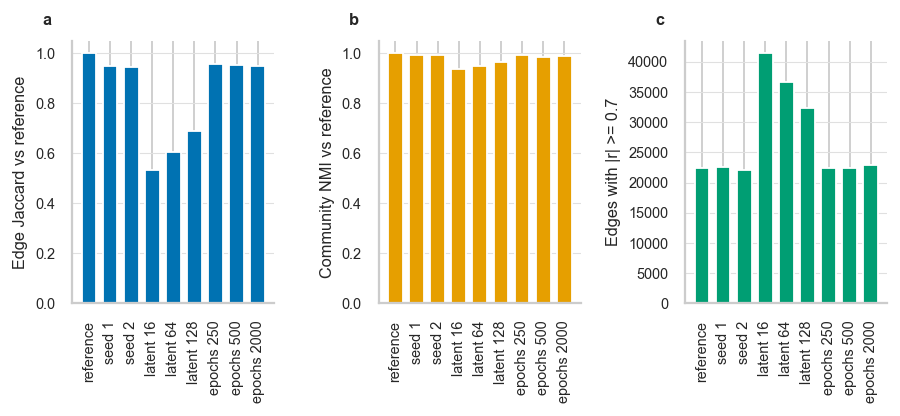

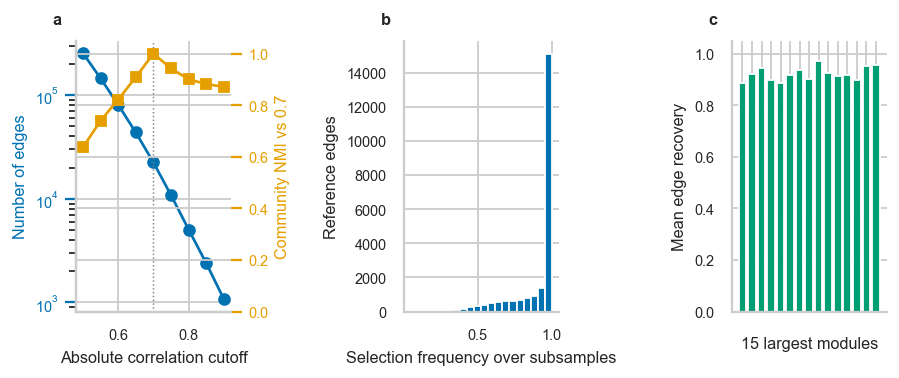

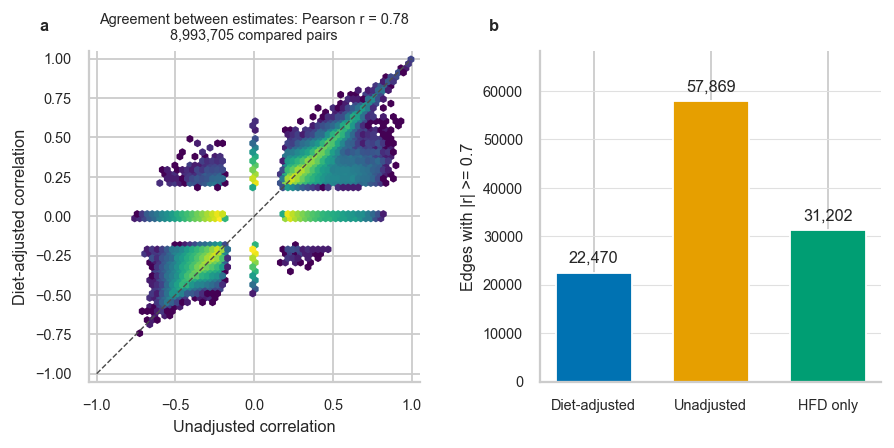

In [33]:
step_start = time.perf_counter()

with plt.rc_context(RC):
    figure_s4()
    reconstruction_table = table_s1()
    figure_s5()
    figure_s6()

print_step_time('Build the supplementary figures and Table S1', step_start)
print('Figures written to', FIG_DIR)

## 10. Key numbers

The table below collects every quantity reported in the manuscript, one per row. It is also written to `key_numbers.csv` next to the tidy results.

In [35]:
rows = []


def add(analysis, label, value):
    """Append one labelled quantity to the key-numbers table."""
    rows.append({'analysis': analysis, 'quantity': label, 'value': float(value)})


# Stage A: observed-only against MetVAE correlations.
stratum_labels = {'all': 'all compared pairs', 'both_observed': 'no-zero pairs', 'any_zero': 'zero pairs'}
if not is_empty(recon_strata):
    for _, row in recon_strata.iterrows():
        name = stratum_labels.get(row['stratum'], row['stratum'])
        add('A reconstruction', f'observed vs MetVAE Pearson r, {name}', row['pearson'])
        add('A reconstruction', f'compared pairs, {name}', row['n_pairs'])
    all_row = recon_strata[recon_strata['stratum'] == 'all'].iloc[0]
    add('A reconstruction', 'observed vs MetVAE edge Jaccard at |r| >= 0.7',
        all_row['edge_jaccard'])

# Stage B: sensitivity.
if not is_empty(sensitivity_summary):
    for _, row in sensitivity_summary.sort_values(['config_order', 'comparison']).iterrows():
        tag = f"{row['config']} vs {row['comparison']}"
        add('B sensitivity', f'{tag}: edge Jaccard', row['edge_jaccard'])
        add('B sensitivity', f'{tag}: estimate Pearson over union support',
            row['estimate_pearson_union'])
        add('B sensitivity', f'{tag}: community NMI', row['community_nmi'])
    base = sensitivity_summary[sensitivity_summary['comparison'] == 'retrained_reference']
    for _, row in base.sort_values('config_order').iterrows():
        add('B sensitivity', f"{row['config']}: edges at |r| >= 0.7", row['n_edges_alt'])
        add('B sensitivity', f"{row['config']}: nodes", row['n_nodes_alt'])

# Stage C: diet adjustment.
for label in DIET_MODEL_LABELS:
    table = diet_edges.get(label)
    if not is_empty(table):
        add('C diet', f'edges at |r| >= 0.7, {label}', len(table))
if not is_empty(diet_comparison):
    for _, row in diet_comparison.iterrows():
        add('C diet', f"edge Jaccard, {row['comparison']}", row['edge_jaccard'])
if not is_empty(diet_contrast):
    for _, row in diet_contrast.iterrows():
        add('C diet', f"median |diet coefficient|, {row['edge_category']} edges",
            row['median_endpoint_abs_coefficient'])
if not is_empty(diet_annotation):
    for _, row in diet_annotation.iterrows():
        add('C diet', f"edges {row['class_a']}-{row['class_b']}, {row['model']}", row['n_edges'])

# Stage D: cutoff sweep.
if not is_empty(threshold_sweep):
    for _, row in threshold_sweep.iterrows():
        cutoff = row['cutoff']
        add('D cutoff', f'edges at cutoff {cutoff:g}', row['n_edges'])
        add('D cutoff', f'nodes at cutoff {cutoff:g}', row['n_nodes'])
        add('D cutoff', f'modules with at least 5 nodes at cutoff {cutoff:g}',
            row['n_communities_min5'])
        add('D cutoff', f'community NMI vs 0.7 at cutoff {cutoff:g}',
            row['nmi_vs_reference_cutoff'])
        add('D cutoff', f'edge Jaccard vs 0.7 at cutoff {cutoff:g}',
            row['edge_jaccard_vs_reference_cutoff'])
if not is_empty(threshold_quantiles):
    for _, row in threshold_quantiles.iterrows():
        add('D cutoff', f"|r| quantile {row['quantile']:g} among supported pairs",
            row['abs_correlation'])
    add('D cutoff', 'supported pairs', threshold_quantiles['n_retained_pairs'].iloc[0])
    add('D cutoff', 'fraction of supported pairs with |r| >= 0.7',
        threshold_quantiles['frac_at_or_above_0.7'].iloc[0])

# Stage D: subsampling.
if not is_empty(subsample_frequency):
    freq = subsample_frequency['selection_frequency'].to_numpy(dtype=float)
    add('D subsampling', 'subsamples', subsample_frequency['n_subsamples'].iloc[0])
    add('D subsampling', 'reference edges assessed', freq.size)
    for level in (0.5, 0.8, 0.9):
        add('D subsampling',
            f'fraction of reference edges with selection frequency >= {level:g}',
            safe_mean(freq >= level))
    add('D subsampling', 'mean selection frequency', safe_mean(freq))
if not is_empty(subsample_communities):
    add('D subsampling', 'mean within-community edge recovery',
        safe_mean(subsample_communities['mean_edge_recovery'].to_numpy(dtype=float)))
    add('D subsampling', 'communities assessed', len(subsample_communities))
if not is_empty(subsample_annotation):
    for _, row in subsample_annotation.iterrows():
        add('D subsampling',
            f"mean selection frequency, {row['class_a']}-{row['class_b']} edges",
            row['mean_selection_frequency'])

key_numbers = pd.DataFrame(rows, columns=['analysis', 'quantity', 'value'])
write_result(key_numbers, 'key_numbers.csv')

with pd.option_context('display.max_rows', None, 'display.width', 160):
    display(key_numbers)


,analysis,quantity,value
0,A reconstruction,"observed vs MetVAE Pearson r, all compared pairs",8.991229e-01
1,A reconstruction,"compared pairs, all compared pairs",8.335689e+06
2,A reconstruction,"observed vs MetVAE Pearson r, no-zero pairs",9.834251e-01
3,A reconstruction,"compared pairs, no-zero pairs",6.797400e+04
4,A reconstruction,"observed vs MetVAE Pearson r, zero pairs",8.982342e-01
5,A reconstruction,"compared pairs, zero pairs",8.267715e+06
6,A reconstruction,observed vs MetVAE edge Jaccard at |r| >= 0.7,4.902143e-01
7,B sensitivity,reference vs reference_estimate: edge Jaccard,1.000000e+00
8,B sensitivity,reference vs reference_estimate: estimate Pear...,1.000000e+00
9,B sensitivity,reference vs reference_estimate: community NMI,1.000000e+00


## Runtime summary

The table below summarizes the timed steps in the order they were recorded.

In [37]:
runtime_summary = pd.Series(step_times, name='seconds').rename_axis('step').reset_index()
display(runtime_summary)
print(f"Total tracked time: {runtime_summary['seconds'].sum():.2f} seconds")

Total tracked time: 5.39 seconds


,step,seconds
0,Load and preprocess data,0.905047
1,Build the supplementary figures and Table S1,4.484446
